In [1]:
import os
import sys

In [2]:
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path

In [3]:
import os
import csv

In [4]:
import json
import warnings
import numpy as np
import csv
csv.field_size_limit(100000000)
        

131072

In [5]:
path = os.path.abspath('')+'/train'
y = []
X2 = []
LABELS = {"enterprise": 0, "cable": 1, "fiber": 2, "hotspot": 3, "eduroam": 4}

In [6]:
from collections import defaultdict
TCP_FLAG_VOCAB = ["SYN", "ACK", "FIN", "PSH", "RST", "URG", "ECE", "CWR"]
FLAG_TO_IDX = {f: i for i, f in enumerate(TCP_FLAG_VOCAB)}
K_FLAGS = len(TCP_FLAG_VOCAB)
def flags_to_multihot(flag_str, vocab=FLAG_TO_IDX):
    vec = np.zeros(len(vocab), dtype=np.float32)
    if not flag_str or flag_str == "NONE":
        return vec
    parts = flag_str.upper().replace(" ", "").split("+")
    for p in parts:
        if p in vocab:
            vec[vocab[p]] = 1.0
    return vec
def _parse_semicolon_list(s, cast=float):
    """Parse a semicolon-separated string into a list with type cast.
    Empty cells or '' return [].
    """
    if s is None:
        return []
    s = s.strip()
    if not s:
        return []
    parts = s.split(";")
    out = []
    for p in parts:
        p = p.strip()
        if p == "":
            # treat empty entries as missing; skip
            continue
        try:
            out.append(cast(p))
        except Exception:
            # if cast fails, skip that element
            continue
    return out

def traffic_csv_converter2(file_path, access_network, target_len=20):
    PAD_VAL = np.nan  # best for XGBoost (native missing handling)

    with open(file_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    if not rows:
        return

    X_list, y_list = [], []

    for row in rows:
        # --- dst_port parsing (keep your original behavior) ---
        try:
            dst_port = int(row.get("dst_ip") and row.get("dst_port") or row["dst_port"])
        except Exception:
            continue

        # skip DNS
        if dst_port == 53:
            continue

        # proto flag (not used below unless you add it as a feature)
        proto = (row.get("proto") or "").upper().strip()
        is_tcp = 1 if proto == "TCP" else 0

        # --- timestamps ---
        ts_sec = _parse_semicolon_list(row.get("timestamps"), cast=float)
        if not ts_sec:
            continue

        ts_ms = np.array(ts_sec, dtype=np.float64) * 1e3

        # remove flows with only 1 packet (or 0)
        if ts_ms.size <= 1:
            continue

        # inter-arrival times (ms)
        iats = np.diff(ts_ms, prepend=ts_ms[0])
        iats[0] = 0.0

        # --- sizes ---
        sizes_list = _parse_semicolon_list(row.get("ip_sizes"), cast=float)
        if len(sizes_list) == 0:
            sizes = np.zeros_like(ts_ms)
        else:
            sizes = np.array(sizes_list, dtype=np.float64)

            # align lengths; if same length, reorder; else trim/pad to match ts_ms
            if len(sizes) == len(ts_ms):
                sizes = sizes
            else:
                sizes = sizes[:len(ts_ms)]
                if len(sizes) < len(ts_ms):
                    sizes = np.pad(
                        sizes,
                        (0, len(ts_ms) - len(sizes)),
                        constant_values=0.0
                    )

        # --- truncate/pad to target_len ---
        L = min(len(ts_ms), target_len)

        feat_iat = iats[:L]
        feat_sz  = sizes[:L]

        if L < target_len:
            pad = target_len - L
            feat_iat = np.pad(feat_iat, (0, pad), constant_values=PAD_VAL)  # NaN pad
            feat_sz  = np.pad(feat_sz,  (0, pad), constant_values=PAD_VAL)  # NaN pad

        # (target_len, 2)
        sample = np.stack([feat_iat, feat_sz], axis=1)
        X_list.append(sample)
        y_list.append(LABELS[access_network])

    if not X_list:
        return

    X2.extend(X_list)
    y.extend(y_list)


In [7]:
ethernet_path = path + "/enterprise"
for file_path in iterate_over_files_in_directory(ethernet_path):
        traffic_csv_converter2(file_path,"enterprise")
modem_path = path + "/cable"
for file_path in iterate_over_files_in_directory(modem_path):
        traffic_csv_converter2(file_path,"cable")
fiber_path = path + "/fiber"
for file_path in iterate_over_files_in_directory(fiber_path):
        traffic_csv_converter2(file_path,"fiber")
hotspot_path = path + "/hotspot"
for file_path in iterate_over_files_in_directory(hotspot_path):
        traffic_csv_converter2(file_path,"hotspot")
# eduroam_path = path + "/eduroam"
# for file_path in iterate_over_files_in_directory(eduroam_path):
#         traffic_csv_converter2(file_path,"eduroam")

In [8]:
y=np.array(y)
X2=np.array(X2)

In [9]:
X2.shape

(139915, 20, 2)

In [10]:
# from sklearn.model_selection import train_test_split
# X_train, X_val,y_train, y_val = train_test_split(
#     X2,
#     y,
#     test_size=0.2,
#     random_state=42,
#     shuffle=True
# )

In [11]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        seq_len: int = 20,
        model_dim: int = 64,
        num_layers: int = 1,
        nhead: int = 2,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.input_ln = nn.LayerNorm(model_dim)
        self.pos_emb = nn.Parameter(torch.zeros(1, seq_len, model_dim))
        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=nhead,
            dim_feedforward=256,
            dropout=0.1,
            activation="relu",
            batch_first=True,
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.attn_pool = nn.Linear(model_dim, 1)
        self.classifier = nn.Linear(model_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.size(1) != self.seq_len:
            raise ValueError(f"Expected seq_len={self.seq_len}, got {x.size(1)}")

        padding_mask = torch.isnan(x).any(dim=-1)
        x = torch.nan_to_num(x, nan=0.0)
        x = self.input_proj(x)
        x = self.input_ln(x)
        x = x + self.pos_emb[:, :x.size(1)]
        x = self.encoder(x, src_key_padding_mask=padding_mask)
        scores = self.attn_pool(x).squeeze(-1)
        scores = scores.masked_fill(padding_mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        pooled = (x * weights.unsqueeze(-1)).sum(dim=1)

        return self.classifier(pooled)

def make_loaders(X, y, batch_size=64, test_size=0.2, seed=42):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=seed, shuffle=True, stratify=y
    )

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=max(64, batch_size), shuffle=False)

    return (X_train, y_train, X_val, y_val, train_loader, val_loader)


def compute_balanced_weights(y_train):
    classes = np.unique(y_train)
    w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    num_classes = int(classes.max()) + 1
    full = np.zeros(num_classes, dtype=np.float32)
    for c, wc in zip(classes, w):
        full[int(c)] = float(wc)
    return full


def train_model(
    model,
    train_loader,
    val_loader,
    class_weights,
    epochs=50,
    device=None,
    patience=10,
    monitor="val_acc",
    save_path="best_model.pt",
    lr=3e-4,
    label_smoothing=0.1
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    w = torch.tensor(class_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=w, label_smoothing=label_smoothing)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_score = None
    best_state = None
    epochs_no_improve = 0

    def improved(curr, best):
        if best is None:
            return True
        return curr > best if monitor == "val_acc" else curr < best

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        total_correct = 0
        total_n = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_n += xb.size(0)

        train_acc = total_correct / max(1, total_n)

        # ---- validate ----
        model.eval()
        v_correct = 0
        v_n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb).argmax(dim=1)
                v_correct += (preds == yb).sum().item()
                v_n += xb.size(0)

        val_acc = v_correct / max(1, v_n)
        print(f"Epoch {epoch:02d} | train acc {train_acc:.4f} | val acc {val_acc:.4f}")

        if improved(val_acc, best_score):
            best_score = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


In [12]:
X_test = []
y_test = []

In [13]:
def test_traffic_csv_converter(file_path, access_network, target_len=20):
    PAD_VAL = np.nan  # best for XGBoost (native missing handling)

    with open(file_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    if not rows:
        return

    X_list, y_list = [], []

    for row in rows:
        # --- dst_port parsing (keep your original behavior) ---
        try:
            dst_port = int(row.get("dst_ip") and row.get("dst_port") or row["dst_port"])
        except Exception:
            continue

        # skip DNS
        if dst_port == 53:
            continue

        # proto flag (not used below unless you add it as a feature)
        proto = (row.get("proto") or "").upper().strip()
        is_tcp = 1 if proto == "TCP" else 0

        # --- timestamps ---
        ts_sec = _parse_semicolon_list(row.get("timestamps"), cast=float)
        if not ts_sec:
            continue

        ts_ms = np.array(ts_sec, dtype=np.float64) * 1e3

        # remove flows with only 1 packet (or 0)
        if ts_ms.size <= 1:
            continue

        # inter-arrival times (ms)
        iats = np.diff(ts_ms, prepend=ts_ms[0])
        iats[0] = 0.0

        # --- sizes ---
        sizes_list = _parse_semicolon_list(row.get("ip_sizes"), cast=float)
        if len(sizes_list) == 0:
            sizes = np.zeros_like(ts_ms)
        else:
            sizes = np.array(sizes_list, dtype=np.float64)

            # align lengths; if same length, reorder; else trim/pad to match ts_ms
            if len(sizes) == len(ts_ms):
                sizes = sizes
            else:
                sizes = sizes[:len(ts_ms)]
                if len(sizes) < len(ts_ms):
                    sizes = np.pad(
                        sizes,
                        (0, len(ts_ms) - len(sizes)),
                        constant_values=0.0
                    )

        # --- truncate/pad to target_len ---
        L = min(len(ts_ms), target_len)

        feat_iat = iats[:L]
        feat_sz  = sizes[:L]

        if L < target_len:
            pad = target_len - L
            feat_iat = np.pad(feat_iat, (0, pad), constant_values=PAD_VAL)  # NaN pad
            feat_sz  = np.pad(feat_sz,  (0, pad), constant_values=PAD_VAL)  # NaN pad

        # (target_len, 2)
        sample = np.stack([feat_iat, feat_sz], axis=1)
        X_list.append(sample)
        y_list.append(LABELS[access_network])

    if not X_list:
        return

    X_test.extend(X_list)
    y_test.extend(y_list)


In [14]:
path = os.path.abspath('')+'/test'
ethernet_path = path + "/enterprise"
for file_path in iterate_over_files_in_directory(ethernet_path):
        test_traffic_csv_converter(file_path,"enterprise")
modem_path = path + "/cable"
for file_path in iterate_over_files_in_directory(modem_path):
        test_traffic_csv_converter(file_path,"cable")
fiber_path = path + "/fiber"
for file_path in iterate_over_files_in_directory(fiber_path):
        test_traffic_csv_converter(file_path,"fiber")
hotspot_path = path + "/hotspot"
for file_path in iterate_over_files_in_directory(hotspot_path):
        test_traffic_csv_converter(file_path,"hotspot")

In [15]:
X_test = np.array(X_test)
y_test = np.array(y_test)

In [16]:
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [17]:
import os
import time
import random
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def predict_numpy(model, X_np: np.ndarray, batch_size: int = 256, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    X_t = torch.tensor(X_np, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_t),
        batch_size=batch_size,
        shuffle=False
    )

    preds = []
    for (xb,) in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds, axis=0)

def run_one(seed, X2, y, X_test, y_test, save_dir="runs_transformer_5seeds"):
    os.makedirs(save_dir, exist_ok=True)
    set_all_seeds(seed)

    # 1) train/val split changes with seed
    X_train, y_train, X_val, y_val, train_loader, val_loader = make_loaders(
        X2, y, batch_size=64, test_size=0.2, seed=42
    )
    class_weights = compute_balanced_weights(y_train)

    # 2) new model each run
    model = TimeSeriesTransformer(
        input_dim=2,
        num_classes=4,
        seq_len=20,
    )

    # device for accurate timing
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 3) train (early stopping on val_acc) + TIME IT
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    model = train_model(
        model,
        train_loader,
        val_loader,
        class_weights,
        epochs=100,
        patience=5,
        monitor="val_acc",
        save_path=os.path.join(save_dir, f"best_model_seed{seed}.pt"),
        lr=3e-4,
    )

    if device == "cuda":
        torch.cuda.synchronize()
    train_time_s = time.perf_counter() - t0

    # 4) Evaluate on VAL + TIME IT
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    y_val_pred = predict_numpy(model, X_val, batch_size=256, device=device)

    if device == "cuda":
        torch.cuda.synchronize()
    val_infer_time_s = time.perf_counter() - t1

    val_metrics = {
        "acc": float(accuracy_score(y_val, y_val_pred)),
        "macro_f1": float(f1_score(y_val, y_val_pred, average="macro")),
        "weighted_f1": float(f1_score(y_val, y_val_pred, average="weighted")),
        "macro_precision": float(precision_score(y_val, y_val_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_val, y_val_pred, average="macro", zero_division=0)),
        "cm": confusion_matrix(y_val, y_val_pred),
        "infer_time_s": float(val_infer_time_s),
        "infer_time_per_sample_ms": float(1000.0 * val_infer_time_s / max(1, len(X_val))),
    }

    # 5) Evaluate on TEST (fixed external set) + TIME IT
    if device == "cuda":
        torch.cuda.synchronize()
    t2 = time.perf_counter()

    y_test_pred = predict_numpy(model, X_test, batch_size=256, device=device)

    if device == "cuda":
        torch.cuda.synchronize()
    test_infer_time_s = time.perf_counter() - t2

    test_metrics = {
        "acc": float(accuracy_score(y_test, y_test_pred)),
        "macro_f1": float(f1_score(y_test, y_test_pred, average="macro")),
        "weighted_f1": float(f1_score(y_test, y_test_pred, average="weighted")),
        "macro_precision": float(precision_score(y_test, y_test_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_test, y_test_pred, average="macro", zero_division=0)),
        "cm": confusion_matrix(y_test, y_test_pred),
        "infer_time_s": float(test_infer_time_s),
        "infer_time_per_sample_ms": float(1000.0 * test_infer_time_s / max(1, len(X_test))),
    }

    return {
        "seed": int(seed),
        "train_time_s": float(train_time_s),
        "val": val_metrics,
        "test": test_metrics,
    }

def summarize(results, split="test"):
    metric_keys = ["acc", "macro_f1", "weighted_f1", "macro_precision", "macro_recall"]

    print(f"\n=== Per-run {split.upper()} metrics + inference time ===")
    for r in results:
        m = r[split]
        print(
            f"seed={r['seed']} | "
            f"acc={m['acc']:.4f} | "
            f"macro_f1={m['macro_f1']:.4f} | "
            f"weighted_f1={m['weighted_f1']:.4f} | "
            f"infer_time={m['infer_time_s']:.3f}s | "
            f"per_sample={m['infer_time_per_sample_ms']:.3f}ms"
        )

    # training time summary
    train_times = np.array([r["train_time_s"] for r in results], dtype=np.float64)
    print(f"\n=== TRAIN time Mean ± Std over {len(results)} runs ===")
    if len(train_times) > 1:
        print(f"train_time_s      : {train_times.mean():.3f} ± {train_times.std(ddof=1):.3f}")
    else:
        print(f"train_time_s      : {train_times.mean():.3f}")

    # metrics summary
    print(f"\n=== {split.upper()} Mean ± Std over {len(results)} runs ===")
    for k in metric_keys:
        vals = np.array([r[split][k] for r in results], dtype=np.float64)
        if len(vals) > 1:
            print(f"{k:16s}: {vals.mean():.4f} ± {vals.std(ddof=1):.4f}")
        else:
            print(f"{k:16s}: {vals.mean():.4f}")

    # inference time summary
    infer_times = np.array([r[split]["infer_time_s"] for r in results], dtype=np.float64)
    per_sample = np.array([r[split]["infer_time_per_sample_ms"] for r in results], dtype=np.float64)

    print(f"\n=== {split.upper()} INFERENCE time Mean ± Std over {len(results)} runs ===")
    if len(infer_times) > 1:
        print(f"infer_time_s      : {infer_times.mean():.3f} ± {infer_times.std(ddof=1):.3f}")
        print(f"per_sample_ms     : {per_sample.mean():.3f} ± {per_sample.std(ddof=1):.3f}")
    else:
        print(f"infer_time_s      : {infer_times.mean():.3f}")
        print(f"per_sample_ms     : {per_sample.mean():.3f}")

    # confusion matrices
    cms = np.stack([r[split]["cm"] for r in results], axis=0)
    print(f"\n{split.upper()} confusion matrix mean:\n", cms.mean(axis=0))
    if cms.shape[0] > 1:
        print(f"\n{split.upper()} confusion matrix std:\n", cms.std(axis=0, ddof=1))

seeds = [0, 1, 2, 3, 4]
results = [run_one(s, X2, y, X_test, y_test) for s in seeds]

summarize(results, split="val")
summarize(results, split="test")

/nas/longleaf/home/paulchoi/.local/lib/python3.11/site-packages/torch/nn/modules/transformer.py:408: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


Epoch 01 | train acc 0.4910 | val acc 0.5319
Epoch 02 | train acc 0.5513 | val acc 0.6172
Epoch 03 | train acc 0.6174 | val acc 0.6323
Epoch 04 | train acc 0.6341 | val acc 0.6474
Epoch 05 | train acc 0.6412 | val acc 0.6448
Epoch 06 | train acc 0.6484 | val acc 0.6451
Epoch 07 | train acc 0.6550 | val acc 0.6542
Epoch 08 | train acc 0.6573 | val acc 0.6636
Epoch 09 | train acc 0.6630 | val acc 0.6519
Epoch 10 | train acc 0.6662 | val acc 0.6752
Epoch 11 | train acc 0.6680 | val acc 0.6658
Epoch 12 | train acc 0.6714 | val acc 0.6813
Epoch 13 | train acc 0.6722 | val acc 0.6749
Epoch 14 | train acc 0.6757 | val acc 0.6807
Epoch 15 | train acc 0.6759 | val acc 0.6789
Epoch 16 | train acc 0.6781 | val acc 0.6816
Epoch 17 | train acc 0.6794 | val acc 0.6833
Epoch 18 | train acc 0.6837 | val acc 0.6818
Epoch 19 | train acc 0.6842 | val acc 0.6894
Epoch 20 | train acc 0.6860 | val acc 0.6824
Epoch 21 | train acc 0.6848 | val acc 0.6891
Epoch 22 | train acc 0.6875 | val acc 0.6890
Epoch 23 |

/tmp/paulchoi/30898907/g1416ood06.ll.unc.edu/ipykernel_1798522/2554417738.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_t = torch.tensor(X_np, dtype=torch.float32)


Epoch 01 | train acc 0.4930 | val acc 0.5322
Epoch 02 | train acc 0.5756 | val acc 0.6262
Epoch 03 | train acc 0.6263 | val acc 0.6327
Epoch 04 | train acc 0.6374 | val acc 0.6338
Epoch 05 | train acc 0.6435 | val acc 0.6569
Epoch 06 | train acc 0.6506 | val acc 0.6539
Epoch 07 | train acc 0.6571 | val acc 0.6602
Epoch 08 | train acc 0.6610 | val acc 0.6745
Epoch 09 | train acc 0.6654 | val acc 0.6786
Epoch 10 | train acc 0.6688 | val acc 0.6802
Epoch 11 | train acc 0.6732 | val acc 0.6793
Epoch 12 | train acc 0.6745 | val acc 0.6903
Epoch 13 | train acc 0.6782 | val acc 0.6851
Epoch 14 | train acc 0.6805 | val acc 0.6865
Epoch 15 | train acc 0.6828 | val acc 0.6933
Epoch 16 | train acc 0.6830 | val acc 0.6867
Epoch 17 | train acc 0.6857 | val acc 0.6927
Epoch 18 | train acc 0.6871 | val acc 0.6949
Epoch 19 | train acc 0.6881 | val acc 0.6987
Epoch 20 | train acc 0.6897 | val acc 0.6975
Epoch 21 | train acc 0.6911 | val acc 0.6992
Epoch 22 | train acc 0.6921 | val acc 0.6972
Epoch 23 |

/tmp/paulchoi/30898907/g1416ood06.ll.unc.edu/ipykernel_1798522/2554417738.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_t = torch.tensor(X_np, dtype=torch.float32)


...

Epoch 01 | train acc 0.4864 | val acc 0.5177
Epoch 02 | train acc 0.5446 | val acc 0.5956
Epoch 03 | train acc 0.6082 | val acc 0.6356
Epoch 04 | train acc 0.6269 | val acc 0.6259
Epoch 05 | train acc 0.6384 | val acc 0.6534
Epoch 06 | train acc 0.6438 | val acc 0.6470
Epoch 07 | train acc 0.6494 | val acc 0.6566
Epoch 08 | train acc 0.6549 | val acc 0.6633
Epoch 09 | train acc 0.6580 | val acc 0.6718
Epoch 10 | train acc 0.6632 | val acc 0.6748
Epoch 11 | train acc 0.6638 | val acc 0.6741
Epoch 12 | train acc 0.6682 | val acc 0.6746
Epoch 13 | train acc 0.6707 | val acc 0.6830
Epoch 14 | train acc 0.6729 | val acc 0.6721
Epoch 15 | train acc 0.6749 | val acc 0.6732
Epoch 16 | train acc 0.6753 | val acc 0.6528
Epoch 17 | train acc 0.6774 | val acc 0.6848
Epoch 18 | train acc 0.6793 | val acc 0.6752
Epoch 19 | train acc 0.6814 | val acc 0.6821
Epoch 20 | train acc 0.6825 | val acc 0.6822
Epoch 21 | train acc 0.6822 | val acc 0.6893
Epoch 22 | train acc 0.6870 | val acc 0.6897
Epoch 23 |

/tmp/paulchoi/30898907/g1416ood06.ll.unc.edu/ipykernel_1798522/2554417738.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_t = torch.tensor(X_np, dtype=torch.float32)


Epoch 01 | train acc 0.4920 | val acc 0.5277
Epoch 02 | train acc 0.5571 | val acc 0.6228
Epoch 03 | train acc 0.6230 | val acc 0.6335
Epoch 04 | train acc 0.6358 | val acc 0.6431
Epoch 05 | train acc 0.6420 | val acc 0.6425
Epoch 06 | train acc 0.6483 | val acc 0.6578
Epoch 07 | train acc 0.6511 | val acc 0.6479
Epoch 08 | train acc 0.6548 | val acc 0.6633
Epoch 09 | train acc 0.6617 | val acc 0.6684
Epoch 10 | train acc 0.6656 | val acc 0.6749
Epoch 11 | train acc 0.6685 | val acc 0.6666
Epoch 12 | train acc 0.6730 | val acc 0.6733
Epoch 13 | train acc 0.6757 | val acc 0.6812
Epoch 14 | train acc 0.6758 | val acc 0.6829
Epoch 15 | train acc 0.6799 | val acc 0.6709
Epoch 16 | train acc 0.6814 | val acc 0.6867
Epoch 17 | train acc 0.6849 | val acc 0.6944
Epoch 18 | train acc 0.6858 | val acc 0.6732
Epoch 19 | train acc 0.6864 | val acc 0.6844
Epoch 20 | train acc 0.6882 | val acc 0.6877
Epoch 21 | train acc 0.6895 | val acc 0.6940
Epoch 22 | train acc 0.6920 | val acc 0.6872


/tmp/paulchoi/30898907/g1416ood06.ll.unc.edu/ipykernel_1798522/2554417738.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_t = torch.tensor(X_np, dtype=torch.float32)



=== Per-run VAL metrics + inference time ===
seed=0 | acc=0.7127 | macro_f1=0.7101 | weighted_f1=0.7103 | infer_time=0.257s | per_sample=0.009ms
seed=1 | acc=0.7156 | macro_f1=0.7127 | weighted_f1=0.7127 | infer_time=0.254s | per_sample=0.009ms
seed=2 | acc=0.7224 | macro_f1=0.7205 | weighted_f1=0.7206 | infer_time=0.252s | per_sample=0.009ms
seed=3 | acc=0.7144 | macro_f1=0.7114 | weighted_f1=0.7116 | infer_time=0.250s | per_sample=0.009ms
seed=4 | acc=0.6944 | macro_f1=0.6898 | weighted_f1=0.6898 | infer_time=0.249s | per_sample=0.009ms

=== TRAIN time Mean ± Std over 5 runs ===
train_time_s      : 379.442 ± 125.847

=== VAL Mean ± Std over 5 runs ===
acc             : 0.7119 ± 0.0105
macro_f1        : 0.7089 ± 0.0114
weighted_f1     : 0.7090 ± 0.0115
macro_precision : 0.7104 ± 0.0106
macro_recall    : 0.7113 ± 0.0105

=== VAL INFERENCE time Mean ± Std over 5 runs ===
infer_time_s      : 0.253 ± 0.003
per_sample_ms     : 0.009 ± 0.000

VAL confusion matrix mean:
 [[5135.2  251.4 123

In [55]:
with torch.no_grad():
    y_pred = model(X_test)

In [56]:
y_pred2 = y_pred.argmax(axis=-1)

In [57]:
y_pred2

tensor([3, 2, 0,  ..., 3, 1, 3])

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test, y_pred2, average='macro'), 4)
accuracy = round(accuracy_score(y_test, y_pred2), 4)
average_f1 = round(f1_score(y_test, y_pred2, average='weighted'), 4)
conf_matrix = confusion_matrix(y_test, y_pred2)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')

Macro Average F1 Score: 0.7813
Accuracy: 0.789
Weighted Average F1 Score: 0.7903


In [59]:
conf_matrix

array([[10841,   396,  1939,   285],
       [  485, 11007,  2023,  1087],
       [ 2181,  1341, 10325,   567],
       [  228,  1821,   949, 17565]])

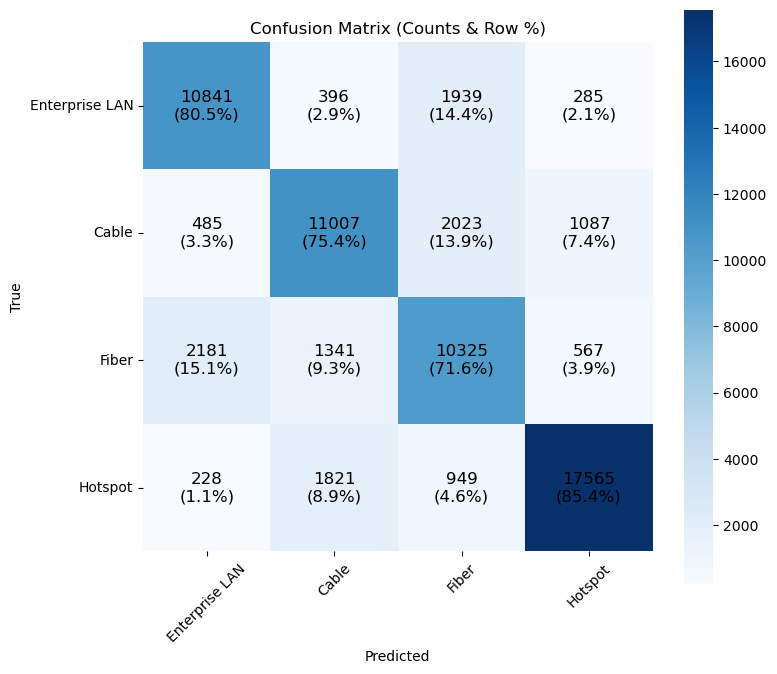

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ["Enterprise LAN","Cable","Fiber","Hotspot"]
M = np.asarray(conf_matrix)
n = M.shape[0]
row_sums = M.sum(axis=1, keepdims=True)
with np.errstate(divide='ignore', invalid='ignore'):
    pct = np.where(row_sums > 0, M / row_sums * 100.0, 0.0)

# Precompute labels
labels = [[f"{int(M[i,j])}\n({pct[i,j]:.1f}%)" for j in range(n)] for i in range(n)]

plt.figure(figsize=(8, 8))
ax = sns.heatmap(
    M, annot=False, cmap="Blues", square=True,
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={"shrink": .8}
)

# Manually place text at cell centers
for i in range(n):
    for j in range(n):
        ax.text(j + 0.5, i + 0.5, labels[i][j],
                ha="center", va="center", fontsize=12)

# (Sometimes needed after manual text with pcolormesh)
ax.set_ylim(n, 0)

ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Counts & Row %)")
ax.tick_params(axis="x", rotation=45); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()
